In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
md = pd.read_csv('medicine.csv')

medf = pd.DataFrame(md)
medf.head(20)

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
0,23,Female,High,High,25.355,meds5
1,47,Male,Low,High,13.093,meds3
2,47,Male,Low,High,10.114,meds3
3,28,Female,Normal,High,7.798,meds4
4,61,Female,Low,High,18.043,meds5
5,22,Female,Normal,High,8.607,meds4
6,49,Female,Normal,High,16.275,meds5
7,41,Male,Low,High,11.037,meds3
8,60,Male,Normal,High,15.171,meds5
9,43,Male,Low,Normal,19.368,meds5


In [4]:
medf.describe(include = 'all')

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,Male,High,High,NaN,meds5
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN


In [5]:
medf.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            200 non-null    int64  
 1   Gender         200 non-null    str    
 2   Blood_Presure  200 non-null    str    
 3   Cholesterol    200 non-null    str    
 4   Ratio_Na_K     200 non-null    float64
 5   Medication     200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [6]:
medf.isnull().sum()

Age              0
Gender           0
Blood_Presure    0
Cholesterol      0
Ratio_Na_K       0
Medication       0
dtype: int64

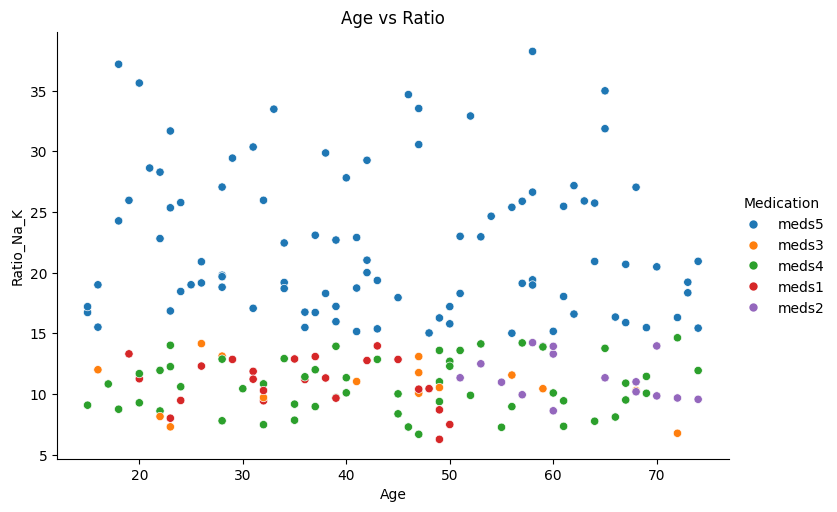

In [7]:
sns.relplot(data = medf, x='Age',y='Ratio_Na_K', hue='Medication',kind='scatter',aspect=1.5,)
##combined scatterplot

plt.title('Age vs Ratio')
plt.show()

Dominance of Meds5 at High Ratios: Patients with a Ratio_Na_K above approximately 15 are almost exclusively prescribed meds5, regardless of their age.

Meds1, Meds3, and Meds4 Cluster at Low Ratios: These three medications are primarily effective for patients with a sodium-potassium ratio below 15.

Age-Based Differentiation for Meds2: Meds2 (purple dots) appears to be targeted specifically at older patients, as it only appearing in the scatter plot for patients aged above 50 with a low sodium-potassium ratio.

Independence from Age for Meds5: The efficacy or prescription of meds5 seems independent of age, as it is distributed consistently across the entire age range (15 to 75+) whenever the Na-K ratio is high.

Overlap in Lower Ratios: There is significant overlap between meds1, meds3, and meds4 for patients under 50 with low ratios, suggesting that for these patients, age and Na-K ratio alone may not be the only deciding factors for choosing between these three.

In [8]:
medf['Medication'].value_counts()

Medication
meds5    91
meds4    54
meds1    23
meds3    16
meds2    16
Name: count, dtype: int64

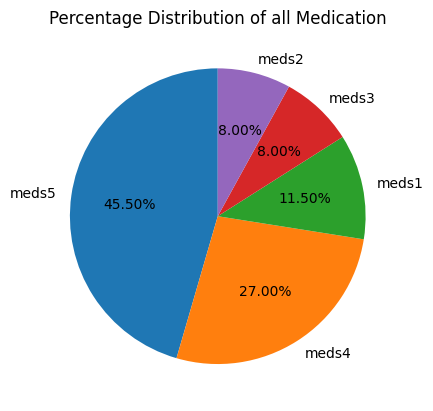

In [9]:
all_med= medf['Medication'].value_counts()


plt.pie(all_med.to_list(),labels=all_med.index,autopct = '%.2f%%', startangle=90)
plt.title('Percentage Distribution of all Medication')
plt.show()

In [10]:
from sklearn.utils import resample

# 1. Separate all classes
df_med5 = medf[medf['Medication'] == 'meds5'] # The Majority (91)
df_med4 = medf[medf['Medication'] == 'meds4']
df_med1 = medf[medf['Medication'] == 'meds1']
df_med2 = medf[medf['Medication'] == 'meds2']
df_med3 = medf[medf['Medication'] == 'meds3']

# 2. Oversample the minorities to match the majority (n=91)
# Repeat this for each minority group
df_med4_upsampled = resample(df_med4, replace=True, n_samples=91, random_state=42)
df_med1_upsampled = resample(df_med1, replace=True, n_samples=91, random_state=42)
df_med2_upsampled = resample(df_med2, replace=True, n_samples=91, random_state=42)
df_med3_upsampled = resample(df_med3, replace=True, n_samples=91, random_state=42)

# 3. Combine them back together
meds_resampled = pd.concat([df_med5, df_med4_upsampled, df_med1_upsampled, df_med2_upsampled, df_med3_upsampled])

# 4. Confirm the balance (Requirement 2.11)
print(meds_resampled['Medication'].value_counts())

Medication
meds5    91
meds4    91
meds1    91
meds2    91
meds3    91
Name: count, dtype: int64


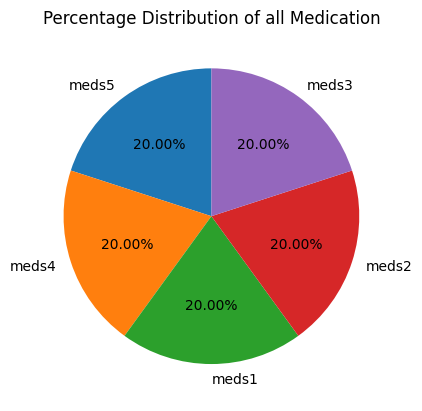

In [11]:
all_med= meds_resampled['Medication'].value_counts()


plt.pie(all_med.to_list(),labels=all_med.index,autopct = '%.2f%%', startangle=90)
plt.title('Percentage Distribution of all Medication')
plt.show()

In [29]:
meds_resampled.head()

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
0,23,Female,High,High,25.355,meds5
4,61,Female,Low,High,18.043,meds5
6,49,Female,Normal,High,16.275,meds5
8,60,Male,Normal,High,15.171,meds5
9,43,Male,Low,Normal,19.368,meds5


In [12]:
for feature in meds_resampled.columns:
    if meds_resampled[feature].dtypes == "object":
        print(f" {feature}: {meds_resampled[feature].unique()}\n")

In [13]:
meds_resampled['Medication'].unique()

<StringArray>
['meds5', 'meds4', 'meds1', 'meds2', 'meds3']
Length: 5, dtype: str

In [14]:
label_Encoder = LabelEncoder()

meds_resampled['Gender'] = label_Encoder.fit_transform(meds_resampled['Gender'])
meds_resampled['Cholesterol'] = label_Encoder.fit_transform(meds_resampled['Cholesterol'])
meds_resampled['Blood_Presure'] = label_Encoder.fit_transform(meds_resampled['Blood_Presure'])
meds_resampled['Medication'] = label_Encoder.fit_transform(meds_resampled['Medication'])



meds_resampled.head()

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
0,23,0,0,0,25.355,4
4,61,0,1,0,18.043,4
6,49,0,2,0,16.275,4
8,60,1,2,0,15.171,4
9,43,1,1,1,19.368,4


In [15]:
meds_resampled.dtypes

Age                int64
Gender             int64
Blood_Presure      int64
Cholesterol        int64
Ratio_Na_K       float64
Medication         int64
dtype: object

In [16]:
corr= meds_resampled.corr()
corr

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
Age,1.000000,0.132304,-0.044432,-0.037919,-0.062936,-0.007988
Gender,0.132304,1.000000,-0.071337,-0.012746,-0.167157,-0.115731
Blood_Presure,-0.044432,-0.071337,1.000000,-0.173612,0.009154,0.620225
Cholesterol,-0.037919,-0.012746,-0.173612,1.000000,0.022734,-0.009375
Ratio_Na_K,-0.062936,-0.167157,0.009154,0.022734,1.000000,0.570322
Medication,-0.007988,-0.115731,0.620225,-0.009375,0.570322,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

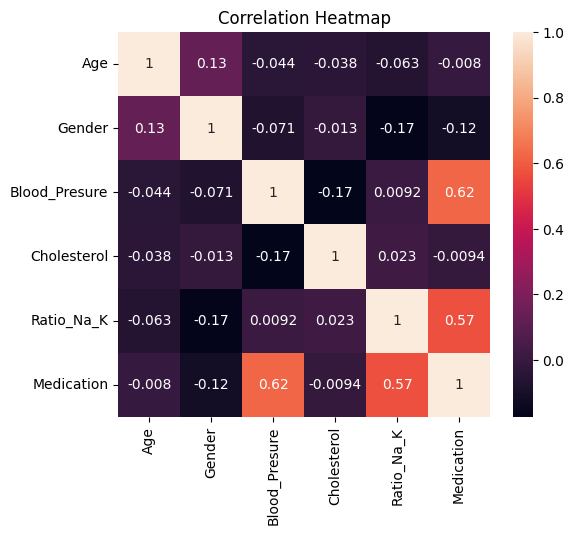

In [17]:
plt.figure(figsize=(6,5))
heat = sns.heatmap(data=corr, annot=True)
plt.title('Correlation Heatmap')

Strongest Predictors: Blood_Pressure and Ratio_Na_K have the most significant influence on the medication prescribed, showing strong positive correlations of 0.62 and 0.57 respectively.

Moderate/Weak Influence: Gender shows a weak negative correlation (-0.12) with Medication, suggesting it plays a minor role in the decision-making process.

Negligible Influence: Both Age (-0.008) and Cholesterol (-0.0094) have correlation values very close to zero, indicating that they have almost no linear relationship with the type of medication prescribed in this specific view of the data.

Feature Independence: Most input features (like Age and Ratio_Na_K) show very low correlation with each other, meaning they likely provide independent information to a machine learning model.

In [56]:
meds_resampled.head()

,Age,Gender,Blood_Presure,Cholesterol,Ratio_Na_K,Medication
0,23,0,0,0,25.355,4
4,61,0,1,0,18.043,4
6,49,0,2,0,16.275,4
8,60,1,2,0,15.171,4
9,43,1,1,1,19.368,4


In [18]:
from sklearn.model_selection import train_test_split

X = meds_resampled.drop(['Medication'],axis = 1)
y= meds_resampled['Medication'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 13)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
scaler.fit(X_test)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(364, 5)
(364,)
(91, 5)
(91,)


KNN(acc): 0.909475 (0.046212)
KNN(f1): 0.897674 (0.057462)


C:\Users\mnqob\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\mnqob\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\mnqob\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mnqob\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "C:\Users\mnqob\AppData\Roa

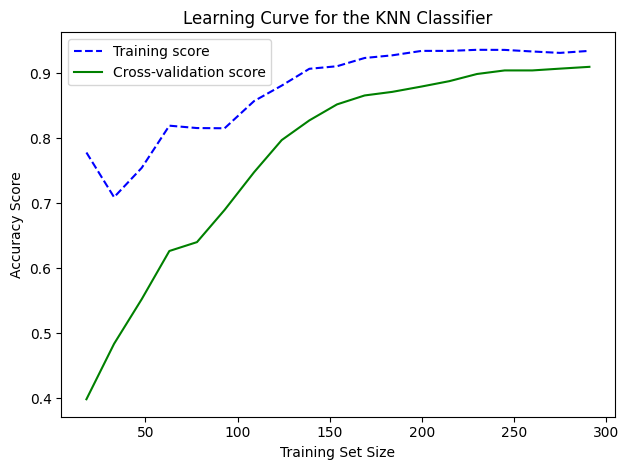

DTC(acc): 0.994521 (0.006711)
DTC(f1): 0.994515 (0.006717)


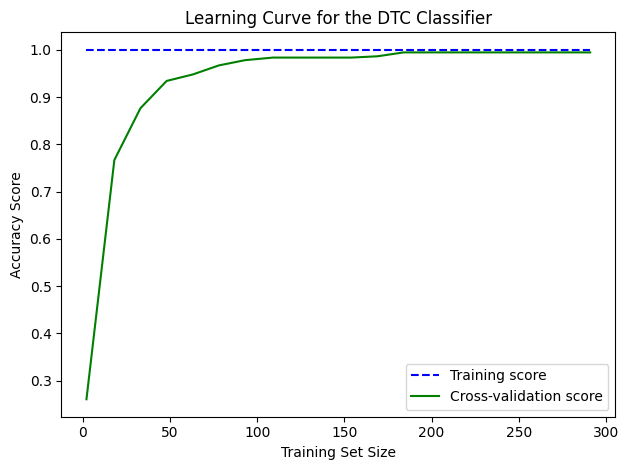

RF(acc): 0.989041 (0.010251)
RF(f1): 0.997283 (0.005434)


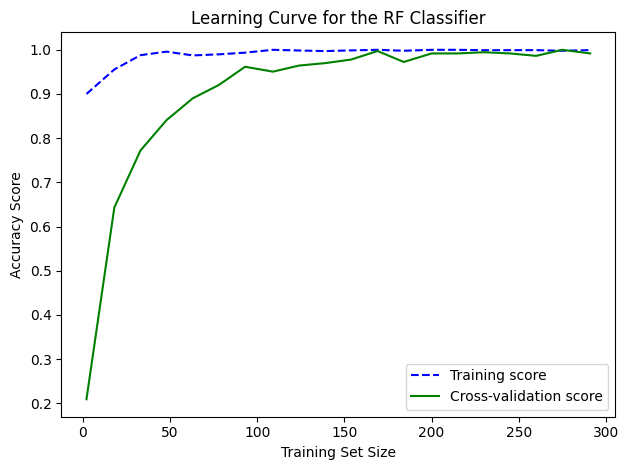

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

models = []

models.append(('KNN',KNeighborsClassifier()))
models.append(('DTC',DecisionTreeClassifier()))
models.append(('RF',RandomForestClassifier(n_estimators=5)))


results = []
names =[]

f1 = make_scorer(f1_score,average = 'weighted')

for name,model in models:
    kfold =KFold(n_splits = 5,random_state=42,shuffle= True)
    cv_results = cross_val_score(model,X_train,y_train,cv=kfold,scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg='%s(acc): %f (%f)' % (name,cv_results.mean(),cv_results.std())
    print(msg)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = f1)
    results.append(cv_results)
    names.append(name)
    msg = '%s(f1): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    train_sizes, train_scores, validation_scores = learning_curve(estimator = model,
                                                              X = X_train,
                                                              y = y_train,
                                                              train_sizes = np.linspace(0.01, 1.0, 20),
                                                              cv = kfold,
                                                              scoring = 'accuracy', shuffle = True)
    mean_training = np.mean(train_scores, axis=1)
    mean_testing = np.mean(validation_scores, axis=1)


    
    plt.plot(train_sizes, mean_training, '--', color = "b",  label = "Training score")
    plt.plot(train_sizes, mean_testing, color = "g", label = "Cross-validation score")
    plt.title(f"Learning Curve for the " + name + " Classifier")
    plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc = "best")
    plt.tight_layout()
    plt.show()


# Alternative

In [20]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = meds_resampled.drop('Medication', axis=1)
y = meds_resampled['Medication']

# Create training/testing dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Determine the dimensions
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X shape: (455, 5), y shape: (455,)
X_train shape: (364, 5), X_test shape: (91, 5)


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=5)
}

# Perform 5-fold cross-validation and report Accuracy and F1 (weighted)
for name, model in models.items():
    cv_results = cross_validate(model, X_train, y_train, cv=5, 
                                scoring=['accuracy', 'f1_weighted'])
    
    print(f"--- {name} ---")
    print(f"CV Training Accuracy: {cv_results['test_accuracy'].mean():.4f}")
    print(f"CV F1 Score: {cv_results['test_f1_weighted'].mean():.4f}\n")

--- KNN ---
CV Training Accuracy: 0.7528
CV F1 Score: 0.7460

--- Decision Tree ---
CV Training Accuracy: 0.9973
CV F1 Score: 0.9973

--- Random Forest ---
CV Training Accuracy: 0.9945
CV F1 Score: 0.9944

